In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [4]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")

In [5]:
customers = customers.drop_duplicates()
orders = orders.drop_duplicates()
order_items = order_items.drop_duplicates()

In [6]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [7]:
customers.to_csv("../data/cleaned/customers_clean.csv", index=False)
orders.to_csv("../data/cleaned/orders_clean.csv", index=False)
order_items.to_csv("../data/cleaned/order_items_clean.csv", index=False)
products.to_csv("../data/cleaned/products_clean.csv", index=False)
payments.to_csv("../data/cleaned/payments_clean.csv", index=False)

In [8]:
conn = sqlite3.connect("../ecommerce.db")

In [9]:
customers.to_sql("customers", conn, if_exists="replace", index=False)
orders.to_sql("orders", conn, if_exists="replace", index=False)
order_items.to_sql("order_items", conn, if_exists="replace", index=False)
products.to_sql("products", conn, if_exists="replace", index=False)
payments.to_sql("payments", conn, if_exists="replace", index=False)

103886

In [10]:
query = """
SELECT order_status, COUNT(*) as total_orders
FROM orders
GROUP BY order_status
"""

df = pd.read_sql(query, conn)
df

,order_status,total_orders
0,approved,2
1,canceled,625
2,created,5
3,delivered,96478
4,invoiced,314
5,processing,301
6,shipped,1107
7,unavailable,609


In [11]:
query = """
SELECT strftime('%Y-%m', order_purchase_timestamp) AS month,
COUNT(order_id) AS total_orders
FROM orders
GROUP BY month
ORDER BY month
"""

monthly_orders = pd.read_sql(query, conn)
monthly_orders

,month,total_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


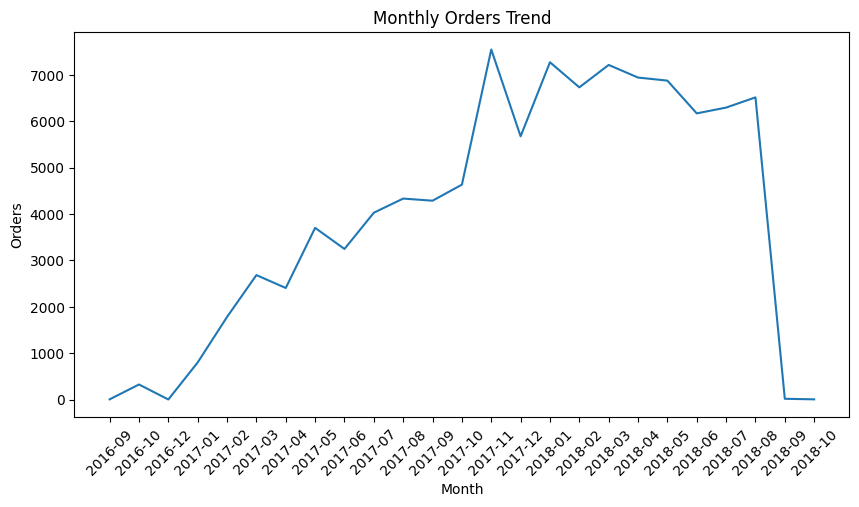

In [12]:
plt.figure(figsize=(10,5))
plt.plot(monthly_orders["month"], monthly_orders["total_orders"])
plt.xticks(rotation=45)
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.show()

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [3]:
conn = sqlite3.connect("../ecommerce.db")

In [4]:
query = """
SELECT
customer_id,
COUNT(order_id) AS total_orders
FROM orders
GROUP BY customer_id
"""

customer_orders = pd.read_sql(query, conn)

customer_orders.head()

,customer_id,total_orders
0,00012a2ce6f8dcda20d059ce98491703,1
1,000161a058600d5901f007fab4c27140,1
2,0001fd6190edaaf884bcaf3d49edf079,1
3,0002414f95344307404f0ace7a26f1d5,1
4,000379cdec625522490c315e70c7a9fb,1


In [5]:
def segment_customer(x):
    if x == 1:
        return "New Customer"
    elif x <= 3:
        return "Regular Customer"
    else:
        return "Loyal Customer"

customer_orders["segment"] = customer_orders["total_orders"].apply(segment_customer)

customer_orders.head()

,customer_id,total_orders,segment
0,00012a2ce6f8dcda20d059ce98491703,1,New Customer
1,000161a058600d5901f007fab4c27140,1,New Customer
2,0001fd6190edaaf884bcaf3d49edf079,1,New Customer
3,0002414f95344307404f0ace7a26f1d5,1,New Customer
4,000379cdec625522490c315e70c7a9fb,1,New Customer


In [6]:
segment_counts = customer_orders["segment"].value_counts()
segment_counts

segment
New Customer    99441
Name: count, dtype: int64

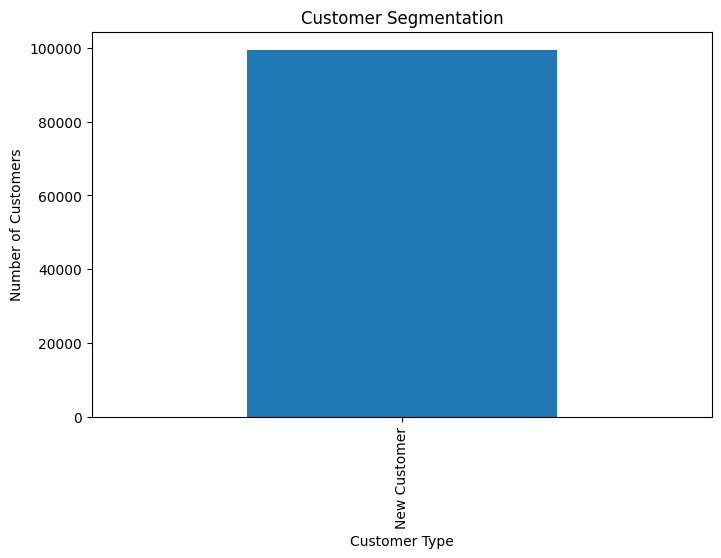

In [7]:
plt.figure(figsize=(8,5))
segment_counts.plot(kind="bar")

plt.title("Customer Segmentation")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

plt.show()

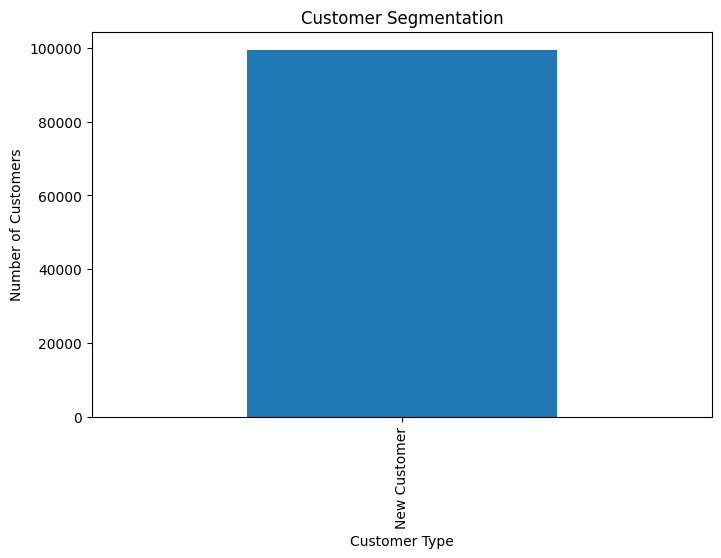

In [8]:
plt.figure(figsize=(8,5))
segment_counts.plot(kind="bar")

plt.title("Customer Segmentation")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

plt.savefig("../dashboard/customer_segmentation.png")
plt.show()

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("../ecommerce.db")

In [3]:
query = """
SELECT 
strftime('%Y-%m', order_purchase_timestamp) AS month,
SUM(payment_value) AS revenue
FROM orders
JOIN payments
ON orders.order_id = payments.order_id
GROUP BY month
ORDER BY month
"""

revenue_trend = pd.read_sql(query, conn)

revenue_trend.head()

,month,revenue
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01


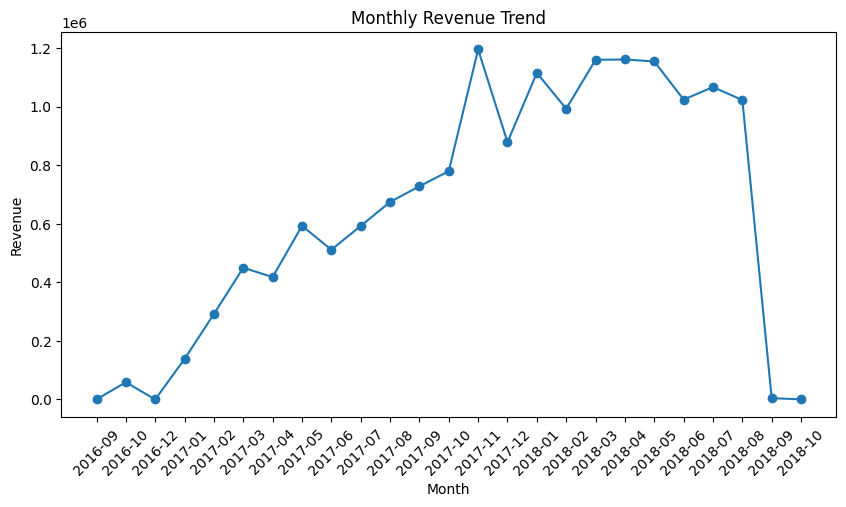

In [4]:
plt.figure(figsize=(10,5))

plt.plot(revenue_trend["month"], revenue_trend["revenue"], marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.savefig("../dashboard/revenue_trend.png")

plt.show()

In [5]:
query = """
SELECT 
product_id,
COUNT(*) AS total_sales
FROM order_items
GROUP BY product_id
ORDER BY total_sales DESC
LIMIT 10
"""

top_products = pd.read_sql(query, conn)

top_products

,product_id,total_sales
0,aca2eb7d00ea1a7b8ebd4e68314663af,527
1,99a4788cb24856965c36a24e339b6058,488
2,422879e10f46682990de24d770e7f83d,484
3,389d119b48cf3043d311335e499d9c6b,392
4,368c6c730842d78016ad823897a372db,388
5,53759a2ecddad2bb87a079a1f1519f73,373
6,d1c427060a0f73f6b889a5c7c61f2ac4,343
7,53b36df67ebb7c41585e8d54d6772e08,323
8,154e7e31ebfa092203795c972e5804a6,281
9,3dd2a17168ec895c781a9191c1e95ad7,274


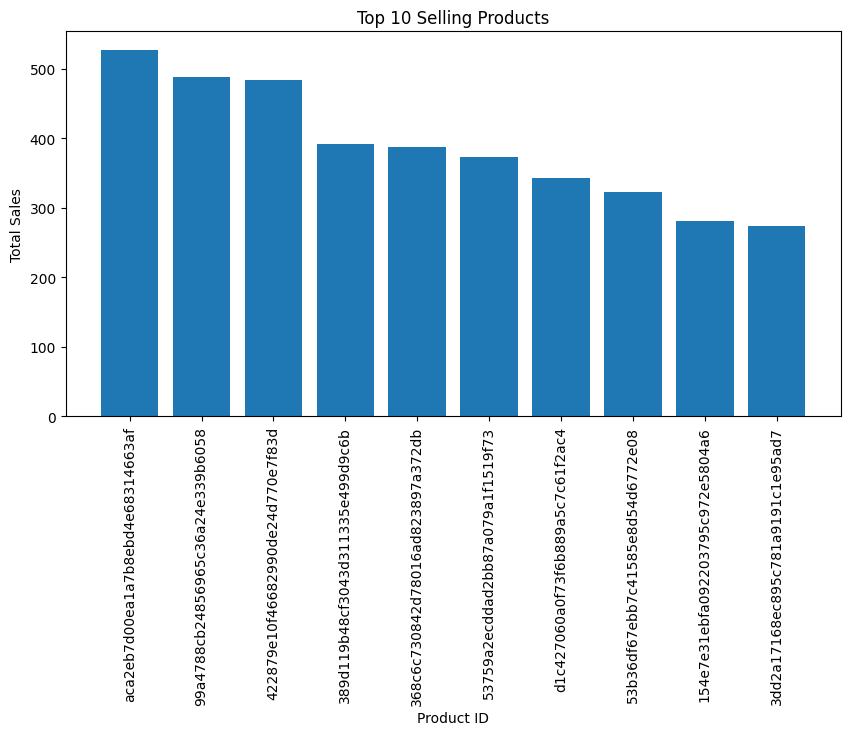

In [6]:
plt.figure(figsize=(10,5))

plt.bar(top_products["product_id"], top_products["total_sales"])

plt.title("Top 10 Selling Products")
plt.xlabel("Product ID")
plt.ylabel("Total Sales")

plt.xticks(rotation=90)

plt.savefig("../dashboard/top_products.png")

plt.show()

In [7]:
query = """
SELECT 
payment_type,
COUNT(*) AS usage_count
FROM payments
GROUP BY payment_type
"""

payment_methods = pd.read_sql(query, conn)

payment_methods

,payment_type,usage_count
0,boleto,19784
1,credit_card,76795
2,debit_card,1529
3,not_defined,3
4,voucher,5775


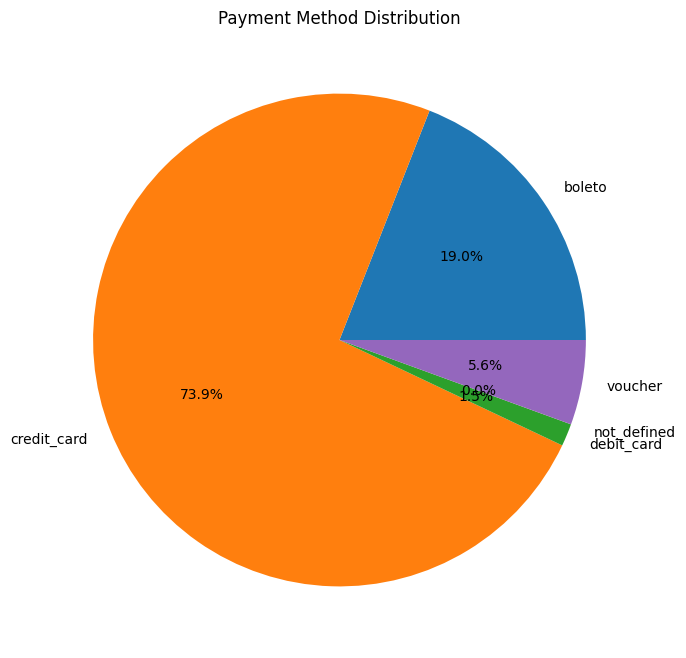

In [14]:
plt.figure(figsize=(8,8))

plt.pie(
payment_methods["usage_count"],
labels=payment_methods["payment_type"],
autopct="%2.1f%%"
)

plt.title("Payment Method Distribution")

plt.savefig("../dashboard/payment_distribution.png")

plt.show()